#**Criminalidade em grandes cidades brasileiras (2015 - 2024)**



# Contexto do Problema:

### A criminalidade é um dos principais desafios enfrentados pelos grandes centros urbanos brasileiros, impactando diretamente:
* segurança pública;
* qualidade de vida;
* desenvolvimento econômico;
* mobilidade urbana;
* percepção de segurança da população.

**A análise de dados criminais permite identificar padrões, regiões mais vulneráveis e períodos críticos, auxiliando no planejamento de políticas públicas e estratégias de prevenção.**

# Perguntas de negócio

* Quais cidades apresentam maior número de ocorrências?
* Quais tipos de crime são mais frequentes?
* Existem horários mais críticos?
* Há crescimento ou redução da criminalidade ao longo do tempo?
* Existem diferenças regionais relevantes?
* Há relação entre renda e criminalidade?

#Dicionário de Dados



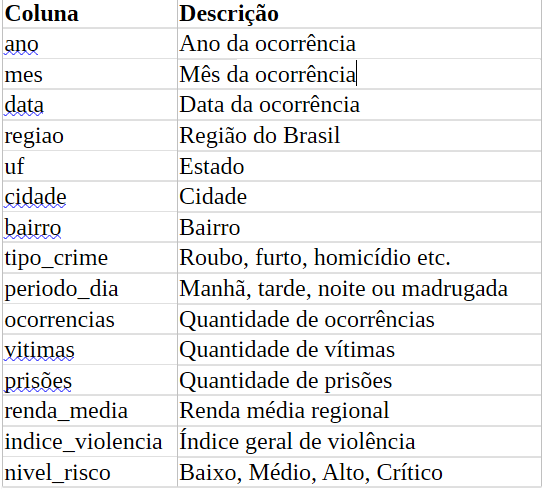

#Importação dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Importando bibliotecas necessárias para análise

In [ ]:
crimes_df = pd.read_csv('simulacao_criminalidade_brasil.csv')
crimes_df.head() # Carregando os dados para análise

,ano,mes,data,regiao,uf,cidade,bairro,tipo_crime,periodo_dia,ocorrencias,vitimas,prisoes,renda_media,indice_violencia,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Manaus,Centro,Estelionato,Madrugada,42,6,5,2391.23,72.87,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,Zona Norte,Furto,Noite,25,4,3,3126.24,85.27,Crítico
2,2015,1,2015-01-01,Norte,PA,Santarém,Periferia,Furto,Manhã,22,1,3,3315.82,73.02,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Zona Sul,Violência doméstica,Tarde,27,5,4,4076.73,106.82,Alto
4,2015,1,2015-01-01,Norte,TO,Palmas,Zona Sul,Estelionato,Madrugada,27,6,4,3494.94,60.85,Crítico


# Inspeção inicial do dataframe

In [ ]:
crimes_df.info() # Verificando tipos de dados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               4440 non-null   int64  
 1   mes               4440 non-null   int64  
 2   data              4440 non-null   object 
 3   regiao            4440 non-null   object 
 4   uf                4440 non-null   object 
 5   cidade            4440 non-null   object 
 6   bairro            4440 non-null   object 
 7   tipo_crime        4440 non-null   object 
 8   periodo_dia       4440 non-null   object 
 9   ocorrencias       4440 non-null   int64  
 10  vitimas           4440 non-null   int64  
 11  prisoes           4440 non-null   int64  
 12  renda_media       4440 non-null   float64
 13  indice_violencia  4440 non-null   float64
 14  nivel_risco       4440 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 520.4+ KB


In [ ]:
crimes_df.isnull().sum() # Quantidade de valores nulos
# Dataframe sem valores nulos(tratado)

,0
ano,0
mes,0
data,0
regiao,0
uf,0
cidade,0
bairro,0
tipo_crime,0
periodo_dia,0
ocorrencias,0


In [ ]:
crimes_df.describe() # Verificando informações estatísticas dos dados como média, desvio padrão, soma e quartis

,ano,mes,ocorrencias,vitimas,prisoes,renda_media,indice_violencia
count,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,2019.500000,6.500000,29.920045,5.004505,2.977252,2781.465045,64.671876
std,2.872605,3.452441,5.432761,2.248371,1.715434,644.155792,31.544017
min,2015.000000,1.000000,14.000000,0.000000,0.000000,689.710000,10.020000
25%,2017.000000,3.750000,26.000000,3.000000,2.000000,2357.447500,37.260000
50%,2019.500000,6.500000,30.000000,5.000000,3.000000,2795.620000,64.795000
75%,2022.000000,9.250000,33.000000,6.000000,4.000000,3209.475000,91.255000
max,2024.000000,12.000000,53.000000,16.000000,12.000000,5138.460000,119.950000


#Análise Exploratória dos dados

In [ ]:
crimes_df.head() # Trazendo as primeiras 5 linhas do dataframe


,ano,mes,data,regiao,uf,cidade,bairro,tipo_crime,periodo_dia,ocorrencias,vitimas,prisoes,renda_media,indice_violencia,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Manaus,Centro,Estelionato,Madrugada,42,6,5,2391.23,72.87,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,Zona Norte,Furto,Noite,25,4,3,3126.24,85.27,Crítico
2,2015,1,2015-01-01,Norte,PA,Santarém,Periferia,Furto,Manhã,22,1,3,3315.82,73.02,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Zona Sul,Violência doméstica,Tarde,27,5,4,4076.73,106.82,Alto
4,2015,1,2015-01-01,Norte,TO,Palmas,Zona Sul,Estelionato,Madrugada,27,6,4,3494.94,60.85,Crítico


* Ranking de Cidades com maior ocorrencia no intervalo de 2015 - 2024

In [ ]:
ranking_cidades = crimes_df.groupby('cidade')['ocorrencias'].sum().sort_values(ascending=False) # Agrupando colunas e apresentando ranking de ocorrencias por cidade
ranking_cidades.head(10)

,ocorrencias
cidade,
Florianópolis,3707
Goiânia,3672
Brasília,3670
Belo Horizonte,3665
Petrópolis,3664
Joinville,3659
Manaus,3652
Campinas,3645
Aparecida de Goiânia,3639


* Ranking de ocorrências por UF

In [ ]:
raking_ufs = crimes_df.groupby('uf')['ocorrencias'].sum().sort_values(ascending=False) # Agrupando colunas e apresentando ranking de ocorrencias por UF
raking_ufs.head(10)

,ocorrencias
uf,
RJ,14384
ES,10804
MG,10757
SP,10692
SC,7366
GO,7311
BA,7234
CE,7176
PE,7124


Insight de negócio: Apesar das cidades de maior ocorrência serem Florianópolis, Goiânia e Brasília, os estados que elas pertencem não estão entre as maiores ocorrências. Isso mostra uma inconsistência nos dados. É necessário olhar para as duas informações, não apenas uma

In [ ]:
tipo_crime_frequentes = crimes_df.groupby('tipo_crime').agg({'ocorrencias': 'sum'}).sort_values(by='ocorrencias', ascending=False) # Tipos de crimes mais frequentes
tipo_crime_frequentes

,ocorrencias
tipo_crime,
Roubo,23440
Tráfico,23337
Estelionato,21887
Violência doméstica,21505
Homicídio,21497
Furto,21179


Insight de negócio: De acordo com a análise acima,Roubo é o tipo de crime com maior ocorrência. Porém, todos os tipos de crimes citados possuem mais de 20.000 ocorrências, o que mostra o tamanho da violência e da criminalidade no país

In [ ]:
uf_violencia = crimes_df.groupby('uf')['indice_violencia'].mean().sort_values(ascending=False) # UF com maior indice de violencia
top10_uf_violentas = uf_violencia.head(10)
top10_uf_violentas

,indice_violencia
uf,
RO,70.458750
MT,68.719750
PE,67.523667
ES,66.578500
MG,66.547639
PR,66.126125
PA,65.137833
RS,64.993792
PB,64.853250


<Axes: title={'center': 'Top 10 Estados mais violentos'}, xlabel='UF', ylabel='Media de Violência'>

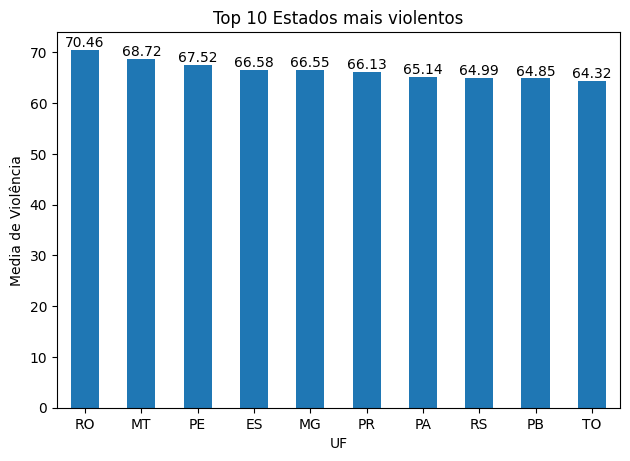

<Figure size 1000x600 with 0 Axes>

In [ ]:
violencia_por_uf_bar = top10_uf_violentas.plot(kind='bar', title='Top 10 Estados mais violentos')
violencia_por_uf_bar.set_ylabel('Media de Violência')
violencia_por_uf_bar.set_xlabel('UF')

for container in violencia_por_uf_bar.containers:
    violencia_por_uf_bar.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.xticks(rotation=0, ha='center')
plt.figure(figsize=(10, 6))
violencia_por_uf_bar

**Insight de negócio: O gráfico acima mostra os Estados mais violentos do Brasil durante os anos apresentados. Rondônia,  Mato Grosso e Pernambuco são o top 3, sendo que a diferença entre o top 1 e o top 10 é considerável**

In [ ]:
violencia_por_regiao = crimes_df.groupby('regiao')['indice_violencia'].mean().sort_values(ascending=False) # Região com maior indice de violencia
violencia_por_regiao

,indice_violencia
regiao,
Norte,65.785467
Sudeste,65.093878
Centro-Oeste,64.801733
Sul,63.971708
Nordeste,63.734094


<Axes: title={'center': 'Regiões com maior indice de violência'}, xlabel='Região', ylabel='Media de Violência'>

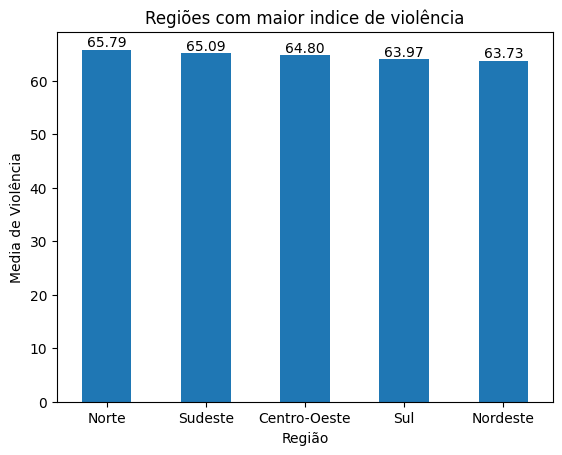

<Figure size 1000x600 with 0 Axes>

In [ ]:
grafico_violencia_por_regiao = violencia_por_regiao.plot(kind='bar', title='Regiões com maior indice de violência')
grafico_violencia_por_regiao.set_ylabel('Media de Violência')
grafico_violencia_por_regiao.set_xlabel('Região')
plt.xticks(rotation=0, ha='center')
plt.figure(figsize=(10, 6))

# Adicionando rótulos
for container in grafico_violencia_por_regiao.containers:
    grafico_violencia_por_regiao.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
grafico_violencia_por_regiao

**Insight de negócio: O norte é o estado mais violento, porém, todos os estados tem um índice muito próximo, o que mostra o quão preocupante é a falta de segurança no Brasil**

<Axes: title={'center': 'Evolução da Criminalidade ao longo dos anos'}, xlabel='ano', ylabel='ocorrencias'>

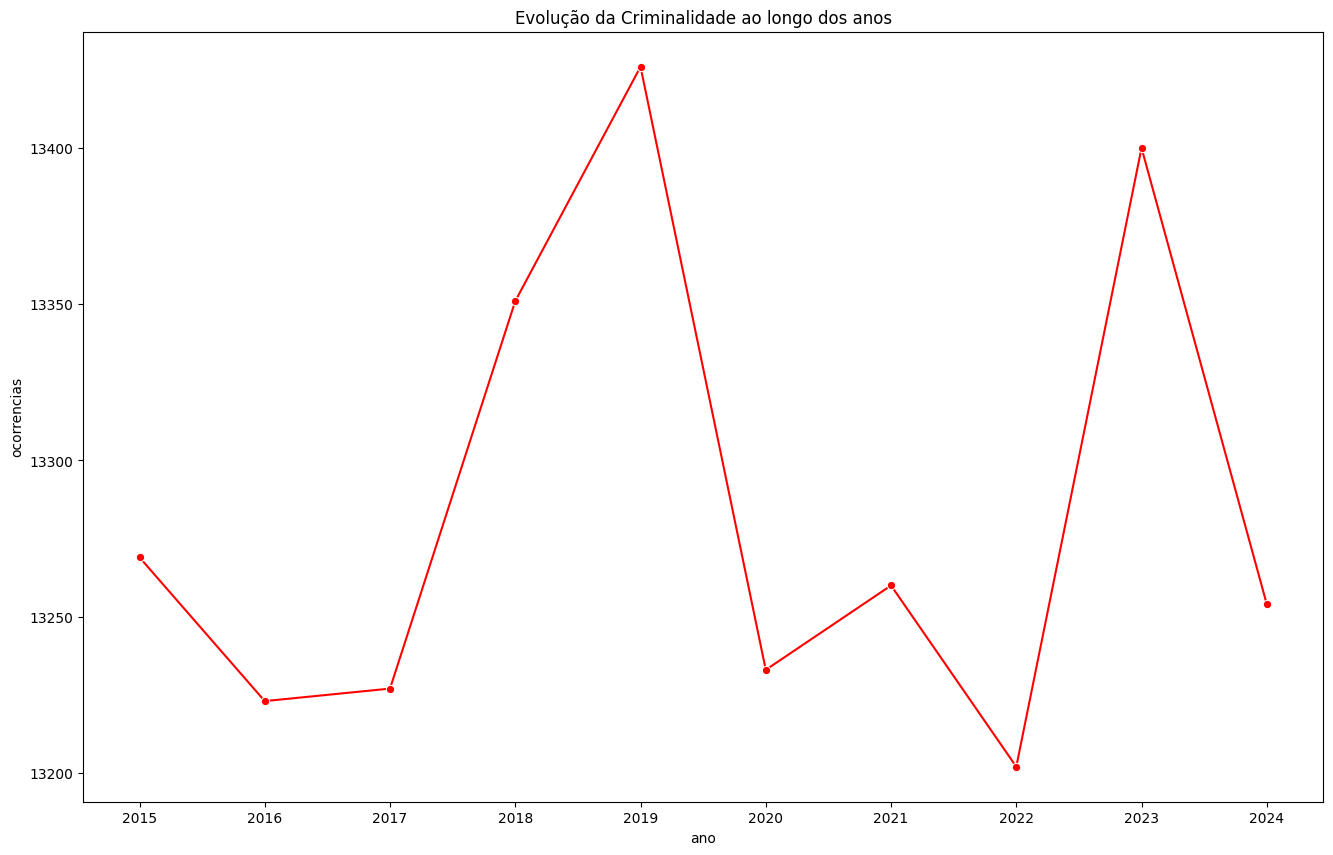

In [ ]:
plt.figure(figsize= (16,10))
criminalidade = crimes_df.groupby('ano')['ocorrencias'].sum()
criminalidade
crime_line = sns.lineplot(data=criminalidade, marker='o', color='red')
plt.title('Evolução da Criminalidade ao longo dos anos')
plt.xticks(crimes_df['ano'].unique())

crime_line

Insight de negócio: O gráfico mostra que os anos de maiores ocorrências são de 2019 e 2023 e uma diminuição muito grande no período de 2020-2022,provavelmente impactado pela pandemia de Covid-19

In [ ]:
periodo_ocorrencias_por_nivel = crimes_df.groupby(['nivel_risco', 'periodo_dia'])['ocorrencias'].count().sort_values(ascending=False)
print("Períodos do dia com maior número de ocorrências por nível de risco:")
print(periodo_ocorrencias_por_nivel)

Períodos do dia com maior número de ocorrências por nível de risco:
nivel_risco  periodo_dia
Crítico      Madrugada      321
Médio        Tarde          311
Alto         Madrugada      298
Baixo        Manhã          295
Alto         Manhã          289
Crítico      Tarde          282
Baixo        Tarde          278
Alto         Noite          276
Crítico      Noite          270
Baixo        Noite          268
             Madrugada      265
Crítico      Manhã          264
Alto         Tarde          263
Médio        Noite          257
             Manhã          256
             Madrugada      247
Name: ocorrencias, dtype: int64


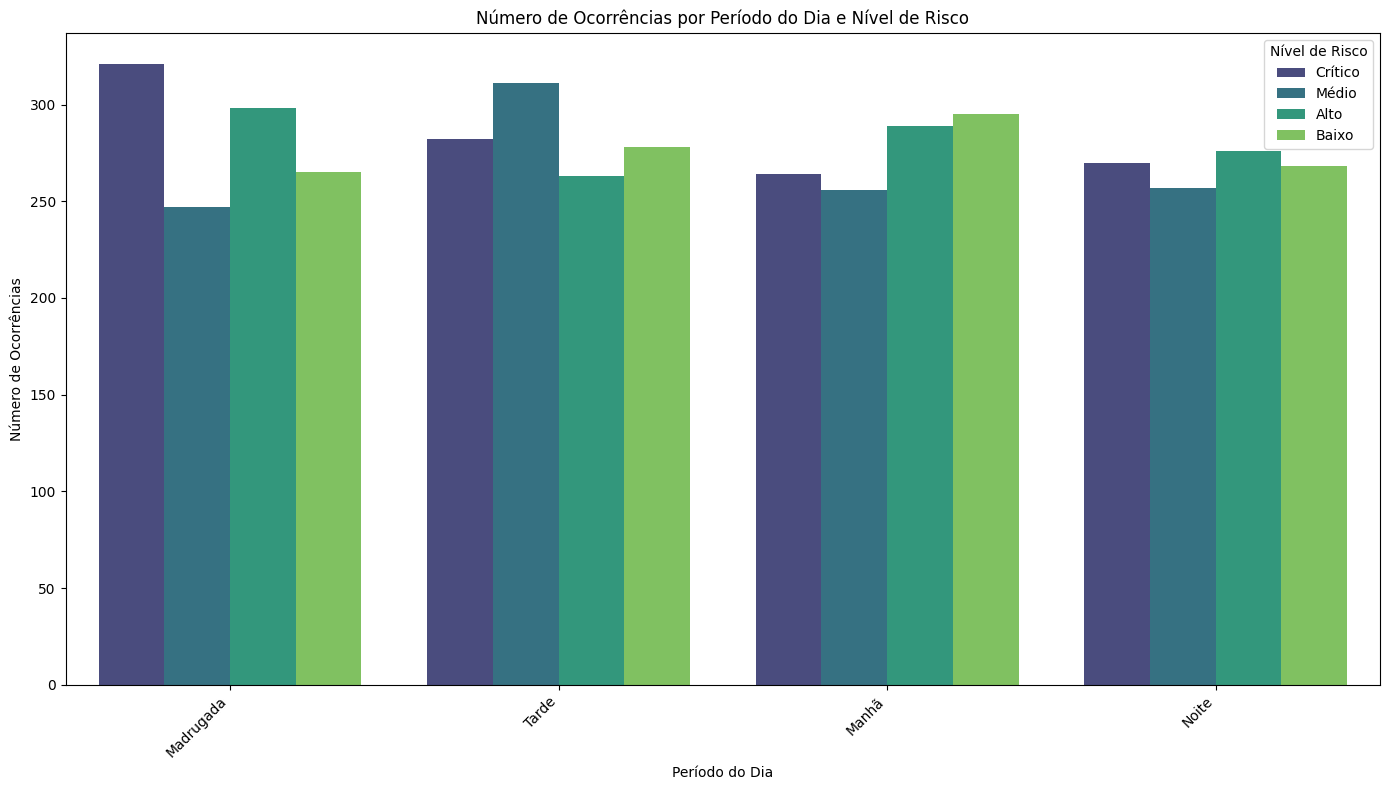

In [ ]:
periodo_ocorrencias_df = periodo_ocorrencias_por_nivel.reset_index()
plt.figure(figsize=(14, 8))
sns.barplot(data=periodo_ocorrencias_df, x='periodo_dia', y='ocorrencias', hue='nivel_risco', palette='viridis')
plt.title('Número de Ocorrências por Período do Dia e Nível de Risco')
plt.xlabel('Período do Dia')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nível de Risco')
plt.tight_layout()
plt.show()

Insight de negócio: A análise mostra que a madrugada possui as ocorrências de maior criticidade(crítico e alto). Além disso, os horário da tarde e da manhã são mais perigosos que os da noite, pois possuem uma quantidade maior de ocorrencias. Esta é uma informação que nem toda população tem conhecimento

In [ ]:
crimes_df['ocorrencias'].sum() # Número total de ocorrencias

np.int64(132845)

In [ ]:
#Correlação entre renda e criminalidade

crimes_df['renda_media']